   PassengerId  Pclass     Sex   Age  SibSp  Parch   Fare Embarked  Survived
0            1       3    male  16.7      2      0  15.96        S         0
1            2       3  female  21.1      0      1  10.49        Q         0
2            3       2  female  36.4      0      1  24.24        S         1
3            4       3  female  50.7      0      0   5.53        S         0
4            5       3    male   NaN      1      0   4.00        C         0

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  400 non-null    int64  
 1   Pclass       400 non-null    int64  
 2   Sex          400 non-null    str    
 3   Age          340 non-null    float64
 4   SibSp        400 non-null    int64  
 5   Parch        400 non-null    int64  
 6   Fare         400 non-null    float64
 7   Embarked     395 non-null    str    
 8   Survived     400 no

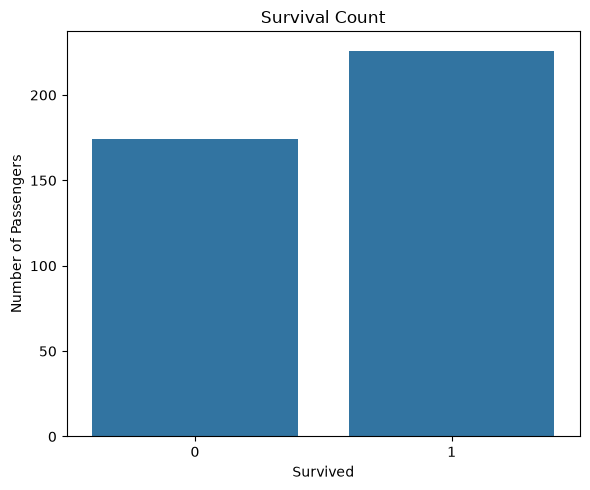

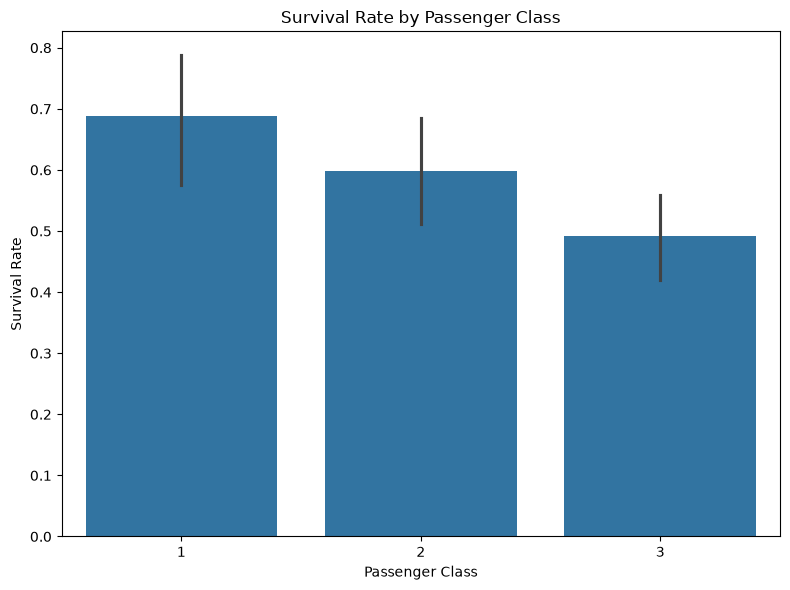

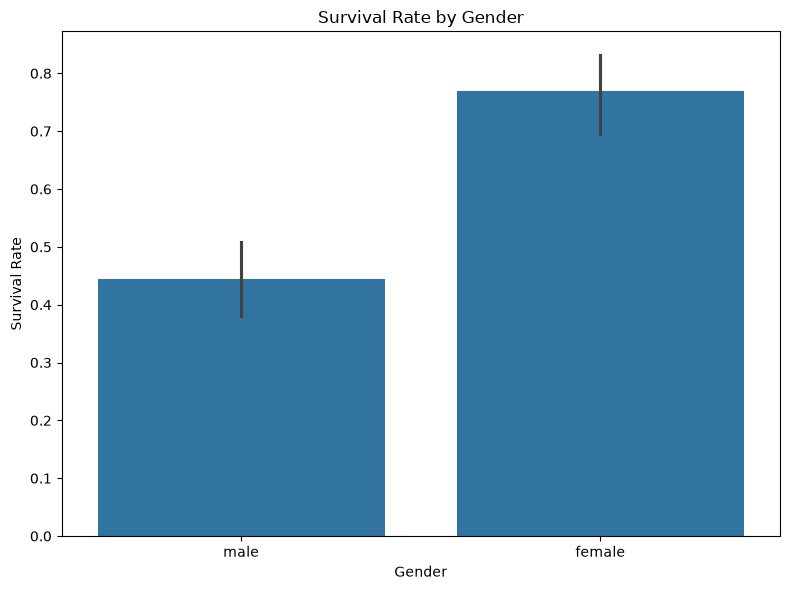

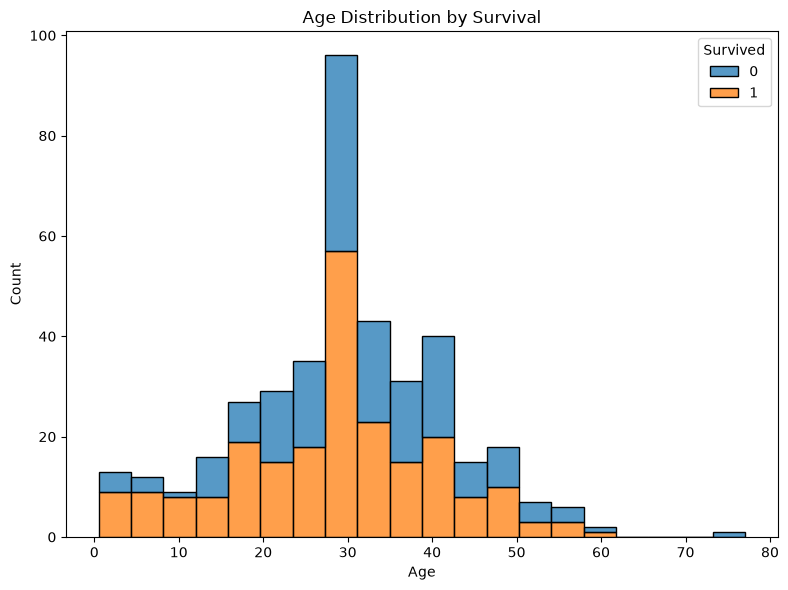

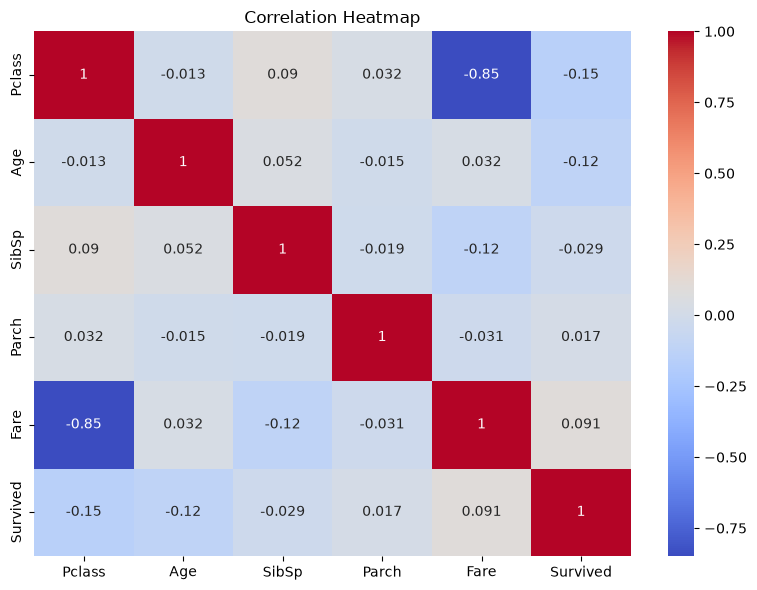

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_data.csv")

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())
print()

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

survival_rate = df["Survived"].mean()
print("Overall survival rate:", survival_rate)

plt.figure(figsize=(6, 5))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", bins=20)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
correlation = df[["Pclass", "Age", "SibSp", "Parch", "Fare", "Survived"]].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Insight

- **Overall survival rate was 56.5%**, slightly better than a coin flip, but this average hides very large gaps between subgroups.
- **Gender was the single strongest predictor of survival** — the "Survival Rate by Gender" chart shows women surviving at a much higher rate than men, consistent with the historical "women and children first" evacuation policy.
- **Passenger class also mattered a lot**: the "Survival Rate by Passenger Class" chart shows 1st class passengers survived at noticeably higher rates than 3rd class, reflecting both cabin location and boarding priority.
- **Age data was incomplete** (60 of 400 records missing, ~15%) and was imputed with the median (30.7); the age-by-survival histogram shows younger passengers had a somewhat better survival rate, though the effect is smaller than gender or class.
- **Fare correlates with survival** in the heatmap — passengers who paid higher fares (typically higher class, better cabin location) had better survival odds, reinforcing that socio-economic status shaped who made it onto the lifeboats.
